In [1]:
# Import required libraries

import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Set dataset path

dataset_path = "/content/drive/MyDrive/mnist_png"

train_path = os.path.join(dataset_path, "training")
test_path = os.path.join(dataset_path, "testing")

Load Dataset Function

In [4]:
# Function to load grayscale images

IMG_SIZE = 28

def load_dataset(folder_path):

    images = []

    for digit in sorted(os.listdir(folder_path)):

        digit_path = os.path.join(folder_path, digit)

        if os.path.isdir(digit_path):

            for image_name in os.listdir(digit_path):

                image_path = os.path.join(digit_path, image_name)

                image = load_img(
                    image_path,
                    color_mode="grayscale",
                    target_size=(IMG_SIZE, IMG_SIZE)
                )

                image = img_to_array(image)

                image = image / 255.0

                images.append(image)

    return np.array(images)

Load Training and Testing Images

In [5]:
# Load training and testing images

train_images = load_dataset(train_path)
test_images = load_dataset(test_path)

print("Training Images :", train_images.shape)
print("Testing Images  :", test_images.shape)

Training Images : (60000, 28, 28, 1)
Testing Images  : (10000, 28, 28, 1)


Visualize Original Images

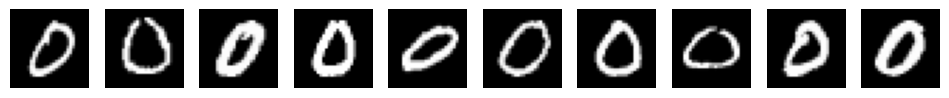

In [6]:
# Display original images

plt.figure(figsize=(12,2))

for i in range(10):

    plt.subplot(1,10,i+1)
    plt.imshow(train_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

Add Gaussian Noise

In [7]:
# Add Gaussian noise

noise_factor = 0.5

x_train_noisy = train_images + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=train_images.shape
)

x_test_noisy = test_images + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=test_images.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

Display Original vs Noisy Images

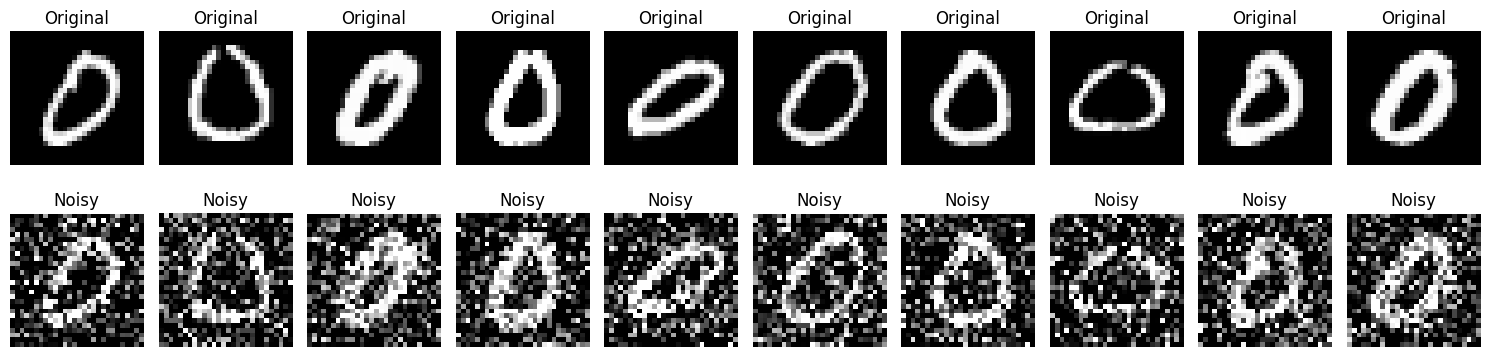

In [8]:
# Compare original and noisy images

plt.figure(figsize=(15,4))

for i in range(10):

    plt.subplot(2,10,i+1)
    plt.imshow(train_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2,10,i+11)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

plt.tight_layout()
plt.show()

Build Autoencoder

In [9]:
# Build denoising autoencoder

input_image = Input(shape=(28,28,1))

x = Conv2D(32, (3,3), activation="relu", padding="same")(input_image)
x = MaxPooling2D((2,2), padding="same")(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2,2), padding="same")(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

autoencoder = Model(input_image, decoded)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

Train Autoencoder

In [10]:
# Train the model

history = autoencoder.fit(
    x_train_noisy,
    train_images,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, test_images)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.1660 - val_loss: 0.1161
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.1132 - val_loss: 0.1086
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1081 - val_loss: 0.1056
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1055 - val_loss: 0.1033
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1037 - val_loss: 0.1021
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1023 - val_loss: 0.1007
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1012 - val_loss: 0.0998
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1003 - val_loss: 0.0994
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0996 - val_loss: 0.0989
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0990 - val_loss: 0.0984
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0984 - val_loss: 0.0977
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/s

Plot Training History

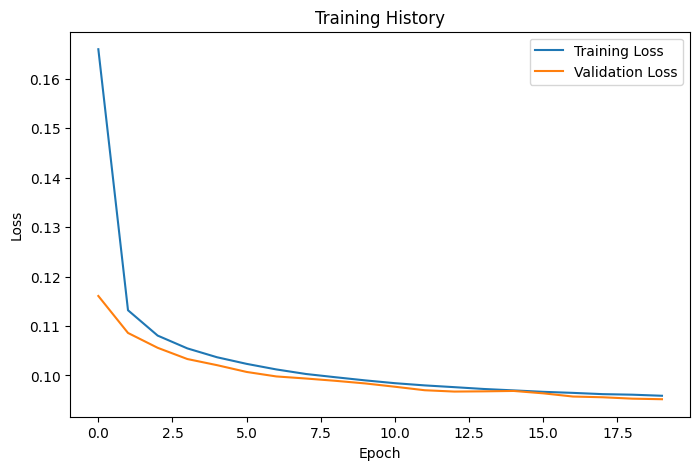

In [11]:
# Plot training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")

plt.legend()

plt.show()

Predict Denoised Images

In [12]:
# Predict denoised images

decoded_images = autoencoder.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Visualize Results

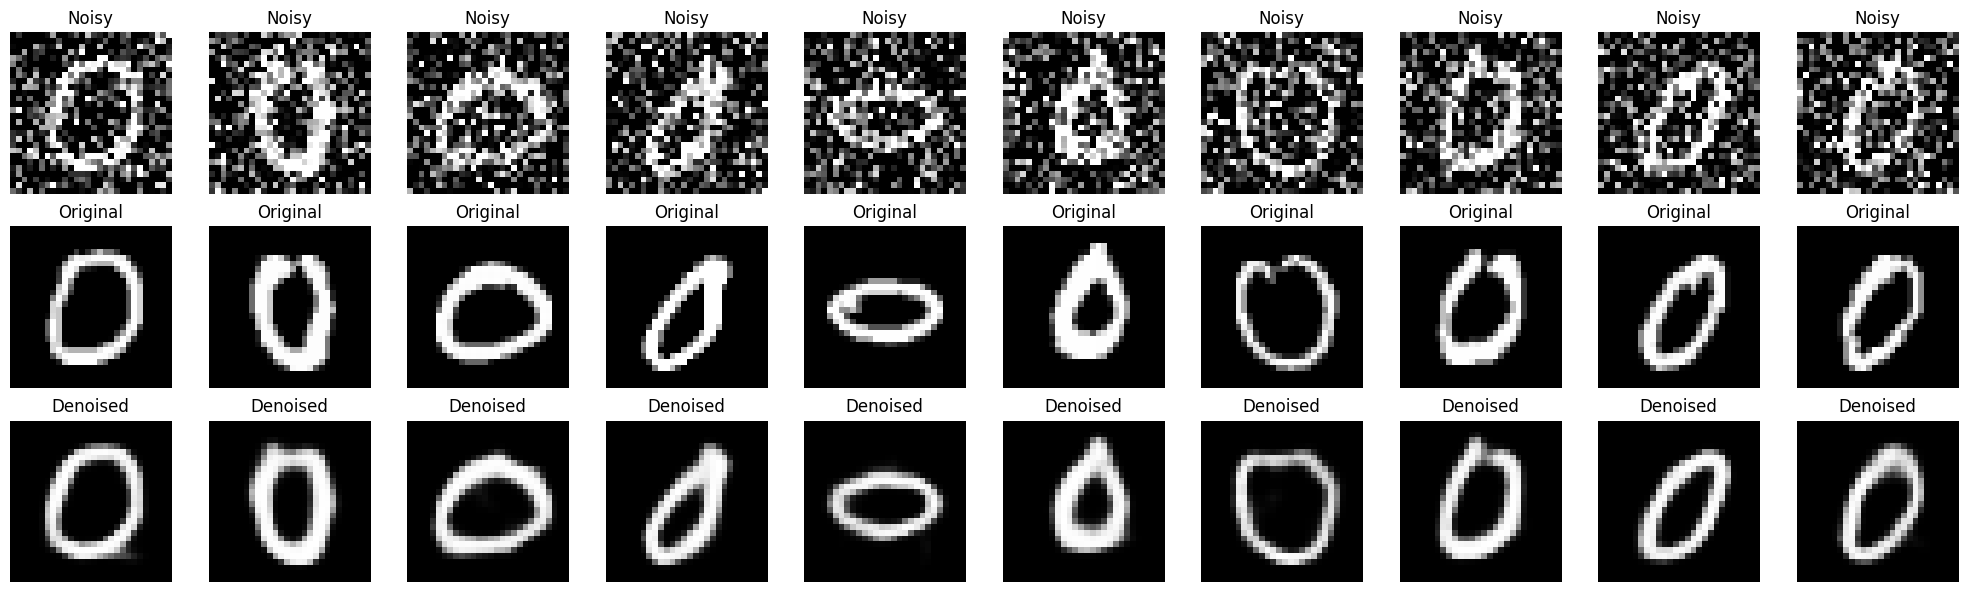

In [13]:
# Display noisy, original and reconstructed images

n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    plt.subplot(3,n,i+n+1)
    plt.imshow(test_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Denoised")

plt.tight_layout()
plt.show()

Calculate MSE

In [14]:
# Calculate Mean Squared Error

mse = np.mean((decoded_images - test_images) ** 2)

print("Mean Squared Error :", mse)

Mean Squared Error : 0.010764107


Calculate PSNR

In [15]:
# Calculate Peak Signal-to-Noise Ratio

psnr = tf.image.psnr(
    decoded_images,
    test_images,
    max_val=1.0
)

print("Average PSNR :", np.mean(psnr))

Average PSNR : 20.009678


Save Model

In [16]:
# Save trained autoencoder

autoencoder.save("mnist_denoising_autoencoder.h5")

print("Model saved successfully.")

Model saved successfully.


Build Deep CNN Autoencoder

In [20]:
# Build improved deep CNN autoencoder

from tensorflow.keras.layers import BatchNormalization

deep_input = Input(shape=(28, 28, 1))

# ---------------- Encoder ----------------

x = Conv2D(32, (3,3), activation="relu", padding="same")(deep_input)
x = BatchNormalization()(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = MaxPooling2D((2,2), padding="same")(x)

x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)

x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2,2), padding="same", name="Latent_Space")(x)

# ---------------- Decoder ----------------

x = Conv2D(64, (3,3), activation="relu", padding="same")(encoded)
x = BatchNormalization()(x)

x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)

x = UpSampling2D((2,2))(x)

output = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

deep_autoencoder = Model(deep_input, output)

deep_autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

deep_autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (MaxPooling2D)     │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,441 (474.38 KB)

 Trainable params: 121,057 (472.88 KB)

 Non-trainable params: 384 (1.50 KB)

Train Deep CNN Autoencoder with Early Stopping & Learning Rate Scheduler

In [21]:
# Train deep CNN autoencoder with callbacks

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_deep_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_deep = deep_autoencoder.fit(
    x_train_noisy,
    train_images,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, test_images),
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ]
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2612
Epoch 1: val_loss improved from None to 0.10427, saving model to best_deep_autoencoder.keras

Epoch 1: finished saving model to best_deep_autoencoder.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 0.1575 - val_loss: 0.1043 - learning_rate: 0.0010
Epoch 2/50
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0996
Epoch 2: val_loss improved from 0.10427 to 0.09629, saving model to best_deep_autoencoder.keras

Epoch 2: finished saving model to best_deep_autoencoder.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.0988 - val_loss: 0.0963 - learning_rate: 0.0010
Epoch 3/50
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0969
Epoch 3: val_loss did not improve from 0.09629
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0964 - val_loss: 0.0977 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0951
Epoch 4: val_loss improved from 0.09629 to 0.09456, saving model 

Compare Training Performance (Basic vs Deep Autoencoder)

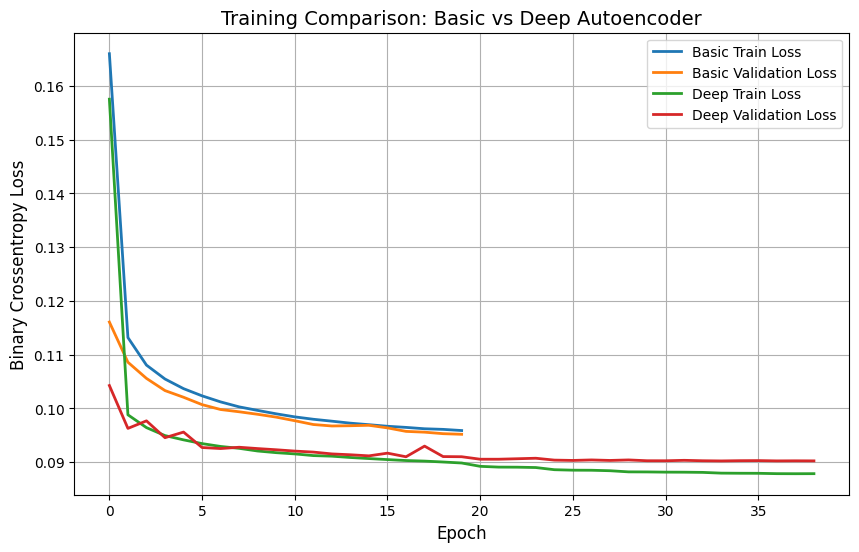

In [22]:
# Plot training history comparison

plt.figure(figsize=(10,6))

plt.plot(
    history.history["loss"],
    label="Basic Train Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Basic Validation Loss",
    linewidth=2
)

plt.plot(
    history_deep.history["loss"],
    label="Deep Train Loss",
    linewidth=2
)

plt.plot(
    history_deep.history["val_loss"],
    label="Deep Validation Loss",
    linewidth=2
)

plt.title("Training Comparison: Basic vs Deep Autoencoder", fontsize=14)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary Crossentropy Loss", fontsize=12)

plt.grid(True)
plt.legend()

plt.show()

Compare Basic vs Deep Autoencoder Outputs

In [23]:
# Generate predictions using both models

basic_decoded_images = autoencoder.predict(x_test_noisy)

deep_decoded_images = deep_autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


Visual Comparison of Both Models

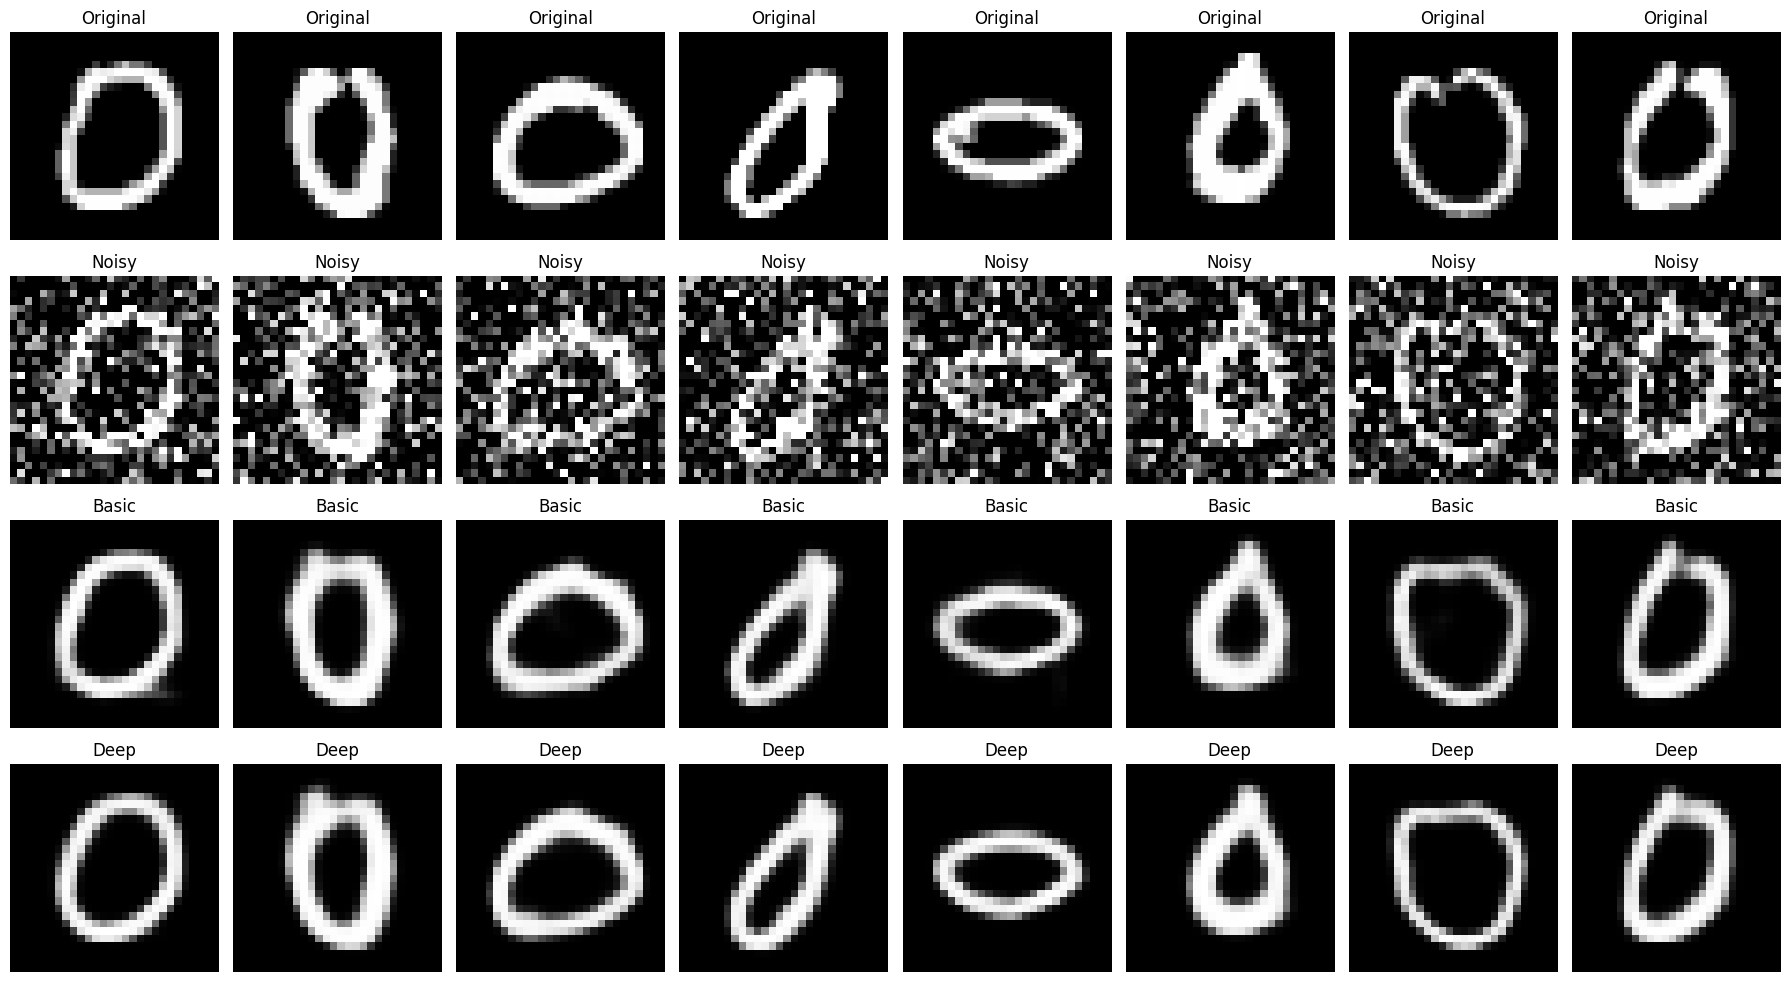

In [24]:
# Compare reconstruction quality of both models

n = 8

plt.figure(figsize=(18,10))

for i in range(n):

    # Original Image
    plt.subplot(4, n, i + 1)
    plt.imshow(test_images[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(4, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Basic Autoencoder
    plt.subplot(4, n, i + 2*n + 1)
    plt.imshow(basic_decoded_images[i].reshape(28,28), cmap="gray")
    plt.title("Basic")
    plt.axis("off")

    # Deep Autoencoder
    plt.subplot(4, n, i + 3*n + 1)
    plt.imshow(deep_decoded_images[i].reshape(28,28), cmap="gray")
    plt.title("Deep")
    plt.axis("off")

plt.tight_layout()
plt.show()

Compare MSE, PSNR and SSIM of Both Models

In [25]:
# Compare reconstruction metrics of both models

from skimage.metrics import structural_similarity as ssim
import pandas as pd

# ---------------- Basic Autoencoder ----------------

basic_mse = np.mean((basic_decoded_images - test_images) ** 2)

basic_psnr = np.mean(
    tf.image.psnr(
        basic_decoded_images,
        test_images,
        max_val=1.0
    )
)

basic_ssim = []

for i in range(len(test_images)):
    score = ssim(
        test_images[i].squeeze(),
        basic_decoded_images[i].squeeze(),
        data_range=1.0
    )
    basic_ssim.append(score)

basic_ssim = np.mean(basic_ssim)

# ---------------- Deep Autoencoder ----------------

deep_mse = np.mean((deep_decoded_images - test_images) ** 2)

deep_psnr = np.mean(
    tf.image.psnr(
        deep_decoded_images,
        test_images,
        max_val=1.0
    )
)

deep_ssim = []

for i in range(len(test_images)):
    score = ssim(
        test_images[i].squeeze(),
        deep_decoded_images[i].squeeze(),
        data_range=1.0
    )
    deep_ssim.append(score)

deep_ssim = np.mean(deep_ssim)

# ---------------- Comparison Table ----------------

comparison = pd.DataFrame({

    "Model":[
        "Basic CNN Autoencoder",
        "Deep CNN Autoencoder"
    ],

    "MSE":[
        basic_mse,
        deep_mse
    ],

    "PSNR":[
        basic_psnr,
        deep_psnr
    ],

    "SSIM":[
        basic_ssim,
        deep_ssim
    ]

})

comparison

,Model,MSE,PSNR,SSIM
0,Basic CNN Autoencoder,0.010764,20.009678,0.866432
1,Deep CNN Autoencoder,0.009223,20.728245,0.888987


Visualize Encoder Feature Maps

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step


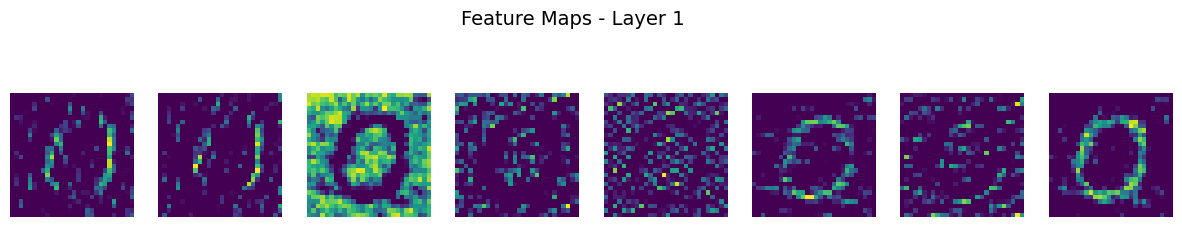

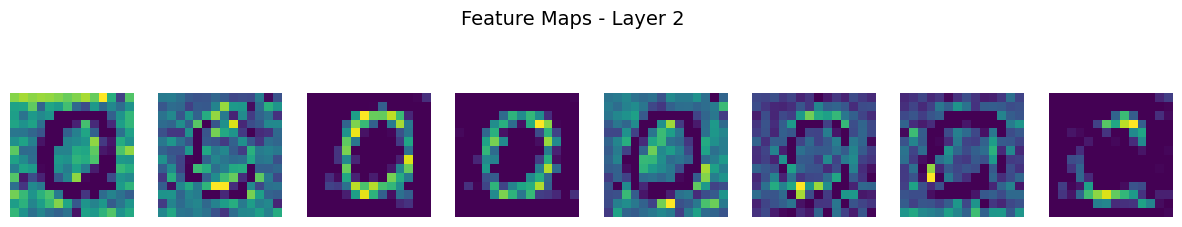

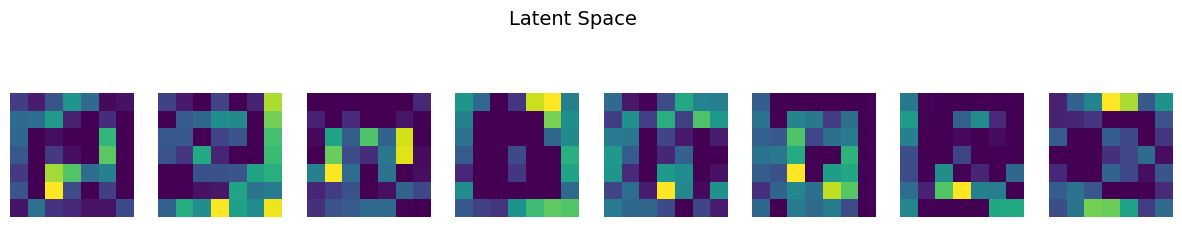

In [26]:
# Visualize feature maps learned by the deep encoder

from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=deep_autoencoder.input,
    outputs=[
        deep_autoencoder.layers[1].output,
        deep_autoencoder.layers[4].output,
        deep_autoencoder.get_layer("Latent_Space").output
    ]
)

sample_image = x_test_noisy[0:1]

feature_maps = feature_extractor.predict(sample_image)

layer_names = [
    "Feature Maps - Layer 1",
    "Feature Maps - Layer 2",
    "Latent Space"
]

for feature_map, name in zip(feature_maps, layer_names):

    num_features = min(feature_map.shape[-1], 8)

    plt.figure(figsize=(15,3))

    for i in range(num_features):

        plt.subplot(1, num_features, i + 1)

        plt.imshow(feature_map[0, :, :, i], cmap="viridis")

        plt.axis("off")

    plt.suptitle(name, fontsize=14)

    plt.show()

Latent Space Visualization using PCA

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


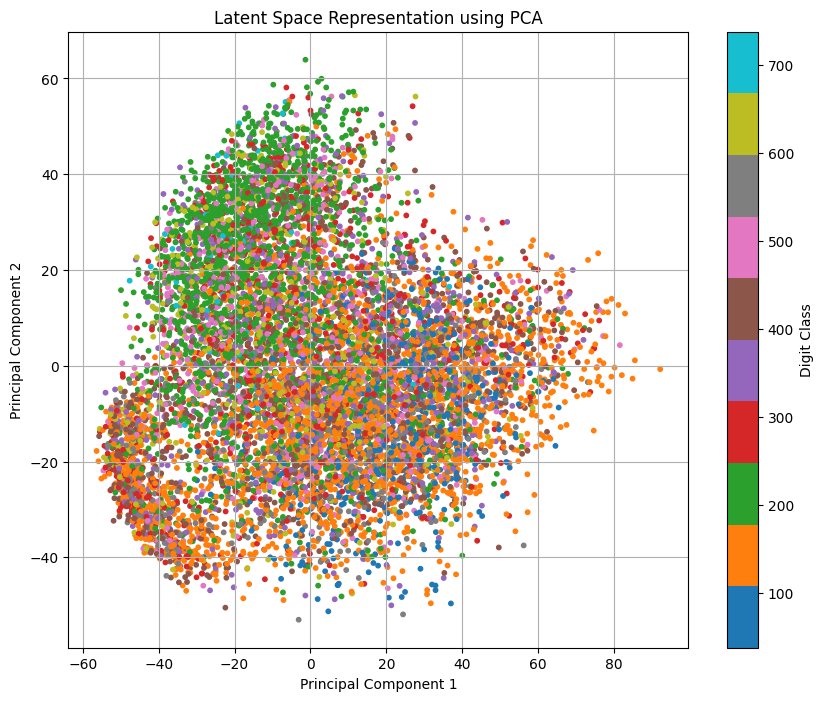

In [27]:
# Visualize latent space using PCA

from sklearn.decomposition import PCA

encoder = Model(
    inputs=deep_autoencoder.input,
    outputs=deep_autoencoder.get_layer("Latent_Space").output
)

latent_features = encoder.predict(x_test_noisy)

latent_features = latent_features.reshape(latent_features.shape[0], -1)

pca = PCA(n_components=2)

latent_pca = pca.fit_transform(latent_features)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    latent_pca[:,0],
    latent_pca[:,1],
    c=np.argmax(test_images.reshape(-1,784), axis=1),
    cmap="tab10",
    s=10
)

plt.title("Latent Space Representation using PCA")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Digit Class")

plt.grid(True)

plt.show()

Evaluate Different Noise Levels

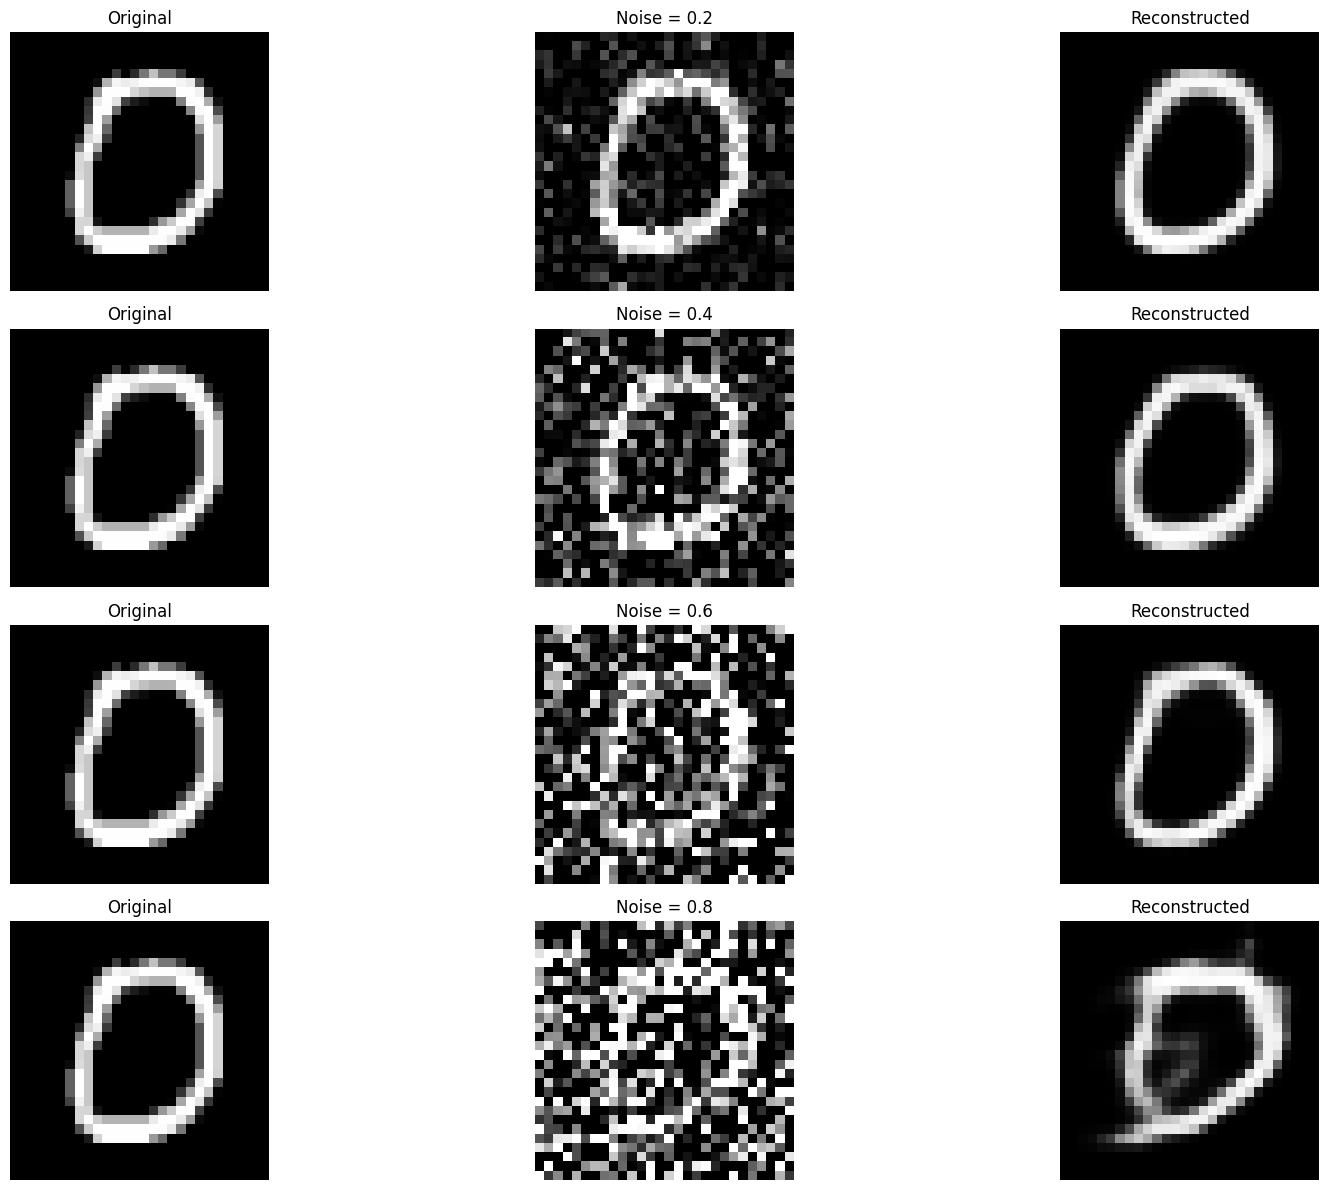

In [28]:
# Evaluate deep autoencoder on different noise levels

noise_levels = [0.2, 0.4, 0.6, 0.8]

plt.figure(figsize=(18, 12))

for row, noise in enumerate(noise_levels):

    noisy_images = test_images + noise * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=test_images.shape
    )

    noisy_images = np.clip(noisy_images, 0., 1.)

    reconstructed_images = deep_autoencoder.predict(
        noisy_images,
        verbose=0
    )

    # Original
    plt.subplot(len(noise_levels), 3, row*3 + 1)
    plt.imshow(test_images[0].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(len(noise_levels), 3, row*3 + 2)
    plt.imshow(noisy_images[0].reshape(28,28), cmap="gray")
    plt.title(f"Noise = {noise}")
    plt.axis("off")

    # Reconstructed
    plt.subplot(len(noise_levels), 3, row*3 + 3)
    plt.imshow(reconstructed_images[0].reshape(28,28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

Visual Performance Comparison (Bar Charts)

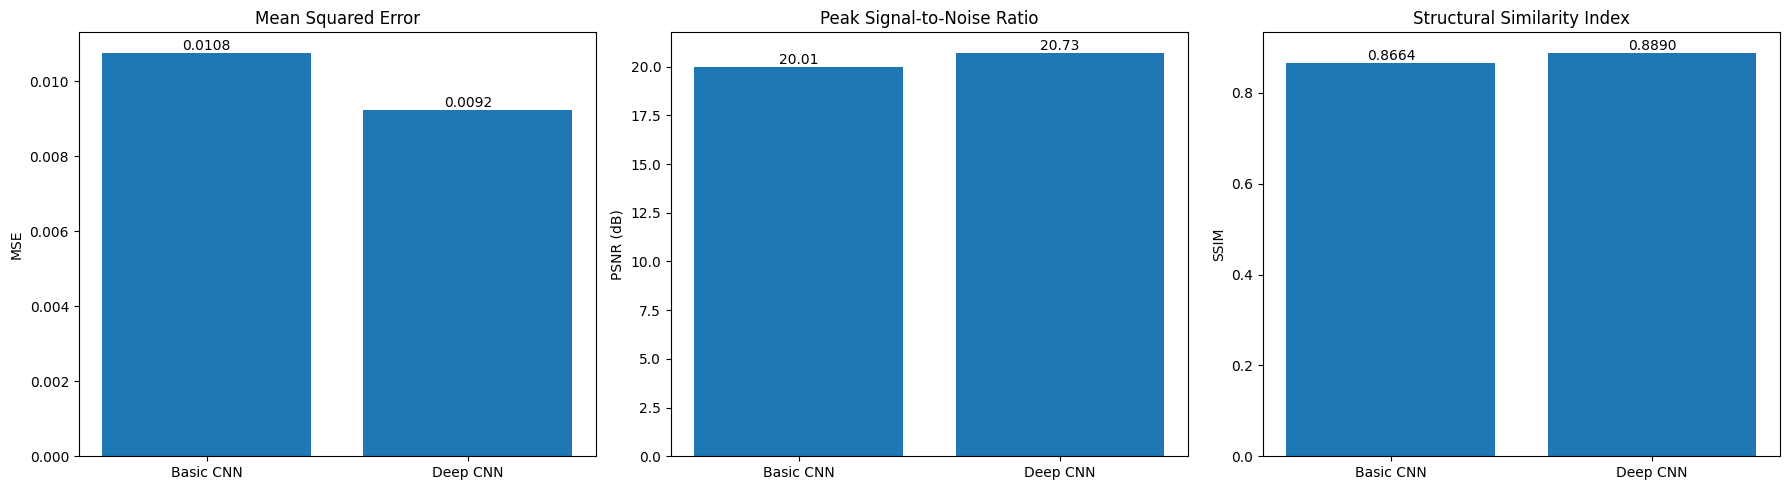

In [29]:
# Visual comparison of evaluation metrics

import matplotlib.pyplot as plt
import numpy as np

models = ["Basic CNN", "Deep CNN"]

mse_values = [basic_mse, deep_mse]
psnr_values = [basic_psnr, deep_psnr]
ssim_values = [basic_ssim, deep_ssim]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# MSE
axes[0].bar(models, mse_values)
axes[0].set_title("Mean Squared Error")
axes[0].set_ylabel("MSE")

for i, value in enumerate(mse_values):
    axes[0].text(i, value, f"{value:.4f}", ha="center", va="bottom")

# PSNR
axes[1].bar(models, psnr_values)
axes[1].set_title("Peak Signal-to-Noise Ratio")
axes[1].set_ylabel("PSNR (dB)")

for i, value in enumerate(psnr_values):
    axes[1].text(i, value, f"{value:.2f}", ha="center", va="bottom")

# SSIM
axes[2].bar(models, ssim_values)
axes[2].set_title("Structural Similarity Index")
axes[2].set_ylabel("SSIM")

for i, value in enumerate(ssim_values):
    axes[2].text(i, value, f"{value:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()